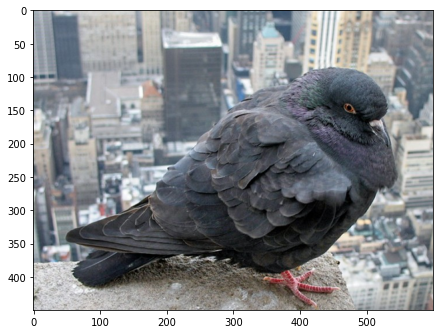

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import rcParams

from os import path
from IPython.display import display
import sys, pdb

import viz

# natural example image:
nimage = Image.open('/home/andrey/data/city_pigeon.png')

# document example image:
# dimage = Image.open('/home/andrey/data/invoice.png')
from pdf2image import convert_from_path
doc_images = convert_from_path('/home/andrey/data/Nomina_diciembre.pdf')
dimage = doc_images[0]
dimage.save('/home/andrey/data/Nomina_diciembre0.png')

from viz import normalise, rshow
from pyramid import gaussian_blur, laplacian_pyramid, inject_noise, bandlimited_noise, get_gaussian_kernel
from oklab import srgb_to_oklab, oklab_to_srgb
from csf import lum_csf, rg_csf, yb_csf    


narr = np.asarray(nimage)
darr = np.asarray(dimage)

source_img = narr


# view a slice of the source img for compactness
yl, yh = 50,500
xl, xh = 100, 700
source_crop = source_img[yl:yh, xl:xh]

rshow(source_crop)

Calculated screen DPI: 81.59
Monitor resolution: 1920*1080, physical size: 27"

Calculated screen dpi: 81.59
Calibration image (600px wide):


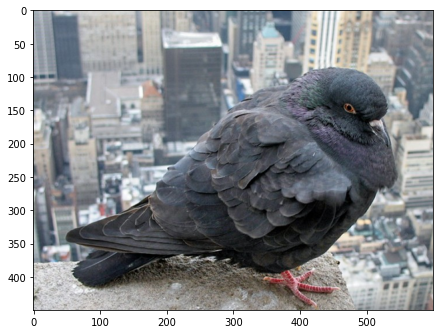

Measured width on screen in cm:
> 12.40
Image screen width 4.9in / horizontal pixel count 600px = perceived ppi 122.9
Ratio between calculated and perceived ppi: 0.664
Effective ppi: 54.2 (used for plotting function only)
Pixels per degree: 36.44
Calibration image at effective ppi, where new perceived_ppi = calculated screen_ppi (81.58915444749253)


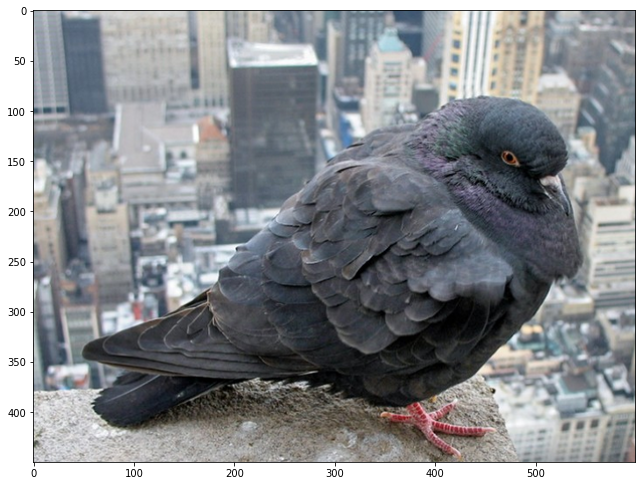

Unscaled image on screen at native resolution should measure exactly: 18.68cm


In [4]:
# calibrate dpi:

from importlib import reload
import viz; reload(viz); import viz

CALIBRATE_DPI = False
calib_img = source_crop

calc_dpi = viz.calib['calc_dpi']

print(f'Monitor resolution: {viz.horiz_px}*{viz.vert_px}, physical size: {viz.diag_inches}"')

print(f'\nCalculated screen dpi: {calc_dpi:.2f}')
calib_w_px = calib_img.shape[1]
print(f'Calibration image ({calib_w_px}px wide):')
rshow(calib_img, dpi=calc_dpi)

print(f'Measured width on screen in cm:')
if CALIBRATE_DPI:
    calib_w_cm = float(str(input('> ')))
else:
    calib_w_cm = 12.4 ### set this value after calibrating and toggling CALIBRATE_DPI=False
    print(f'> {calib_w_cm:.2f}')

calib_w_in = calib_w_cm * 0.393701
perceived_ppi = calib_w_px / calib_w_in

perceived_ppi_ratio = calc_dpi / perceived_ppi
effective_ppi = calc_dpi * perceived_ppi_ratio

print(f'Image screen width {calib_w_in:.1f}in / horizontal pixel count {calib_w_px}px = perceived ppi {perceived_ppi:.1f}')
print(f'Ratio between calculated and perceived ppi: {perceived_ppi_ratio:.3f}')
print(f'Effective ppi: {effective_ppi:.1f} (used for plotting function only)')

# allocate calibrated global vars:
viz.calib['plot_dpi'] = effective_ppi
PPI = viz.calib['calc_dpi'] # true perceived ppi used for frequency calculations
PPcm = PPI / viz.CM_PER_INCH
PPD = viz.get_ppd()   # pixels per visual degree

print(f'Calibration image at effective ppi, where new perceived_ppi = calculated screen_ppi ({calc_dpi})')
rshow(calib_img)
actual_width_in = calib_w_px / calc_dpi
actual_width_cm = actual_width_in / 0.393701
print(f'Unscaled image on screen at native resolution should measure exactly: {actual_width_cm:.2f}cm')



In [398]:
#### laplacian pyramid hyperparameters



    


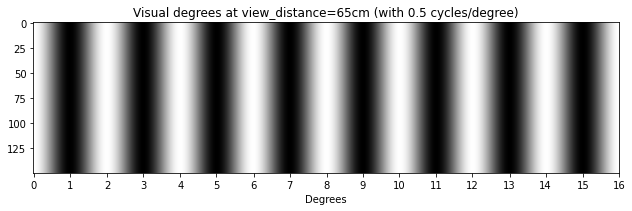

  (Displayed image should measure exactly 18.15cm)


In [5]:
### demonstration of visual degrees and cycle frequency

example_cdeg = 0.5

pxc = PPD / example_cdeg # pixels per cycle

num_degrees = 16

### plot horizontal degrees:
# width_px = int(round(PPD*num_degrees))
# px = np.arange(0, width_px)
height_px = 150

# num_inches = num_px * (1/calib['dpi'])
# figw = num_px / viz.calib['plot_dpi'] # desired figure width in inches
# fig = plt.figure(figsize=(figw,3))


# degrees = np.arange(0, width_px, PPD)
# degrees = np.arange(num_degrees) * PPD # pixel position of each degree
degrees = np.arange(num_degrees+1) # actually the fenceposts BETWEEN degrees, so there are more
degrees_px = np.linspace(0, (num_degrees)*PPD, num_degrees+1) # not including the last
# degrees_px = np.arange(num_degrees+1) * PPD # pixel position of each degree fencepost
# plt.plot(degrees, [1]*len(degrees), 'o', label='1 degree')

width_px = round(max(degrees_px))

cm_per_degree = PPD / PPcm
# target_actual_inches = (width_px / viz.calib['plot_dpi']) * perceived_ppi_ratio
# target_actual_cm = target_actual_inches * viz.CM_PER_INCH
target_actual_cm = cm_per_degree * num_degrees

# build background:
# bg = np.ones((50, num_px))

# # plot cycles: (variable)
# cycles = np.arange(0, px.max(), pxc)
# for c, cval in enumerate(cycles):
#     bg[:,int(round(cval))] = 0 # vertical lines    
#     # plt.axvline(cval, c='black', linewidth=1, label=label)

# def cos_freq(num_cycles, size):
#     w = 2. * np.pi * num_cycles
#     t = np.linspace(0, size, size)
#     sinusoid = np.cos(w*t) # cosine instead of sine to align the peaks with degrees
#     return sinusoid 
def cos_freq(num_cycles, size):
    t = np.linspace(0, 1, size, endpoint=False)
    return np.cos(2 * np.pi * num_cycles * t)


# cycles = cos_freq(num_cycles = (num_degrees * example_cdeg), size=int(round((num_degrees+1)*PPD)))  #=int(round(width_px)))
cycles = cos_freq(num_cycles = (num_degrees * example_cdeg), size=int(round(width_px)))  #=int(round(width_px)))

# bg[:] = normalise(cycles)

### stack up the sine wave vertically:
cycles2d = np.stack([cycles]*height_px)

# plot degrees: (fixed)
# for d in degrees:
#     bg[:,int(d)] = 0 # vertical lines    
ax = rshow(cycles2d, show=False)

plt.xticks(degrees_px.round())
ax.set_xticklabels(degrees)
# plt.yticks([])
plt.xlabel('Degrees')


plt.title(f'Visual degrees at view_distance={viz.view_distance_cm}cm (with {example_cdeg:.1f} cycles/degree)')

plt.show()

# sanity check:
print(f'  (Displayed image should measure exactly {target_actual_cm:.2f}cm)')





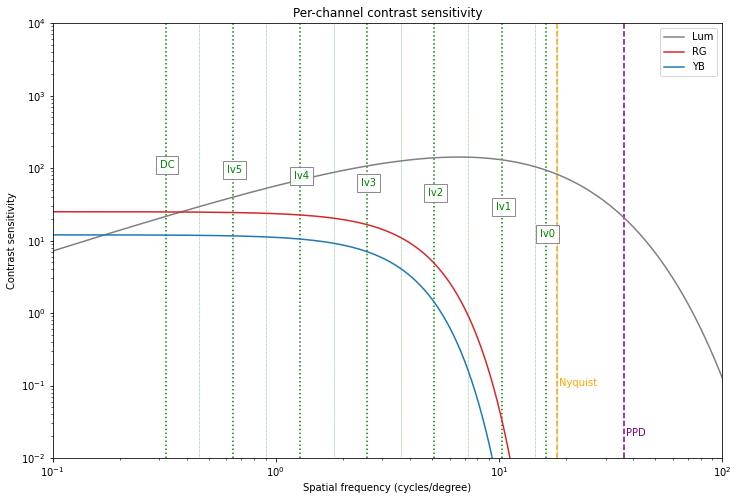

-1. Creating gratings at frequency 16.26 and contrast 0.1


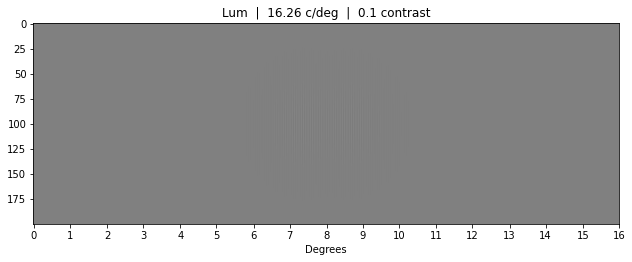

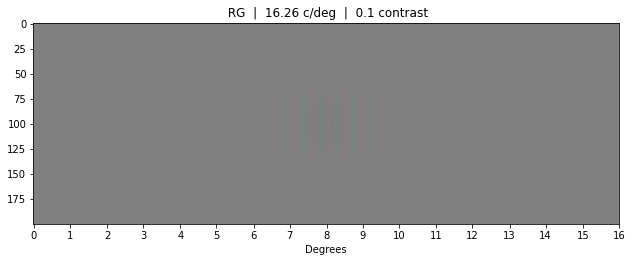

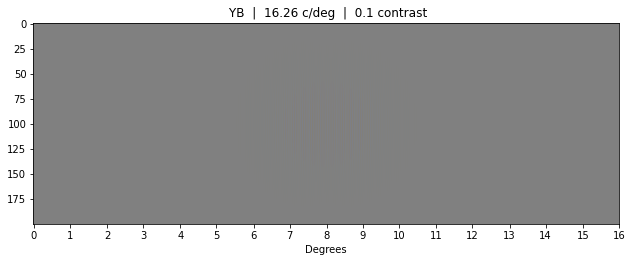

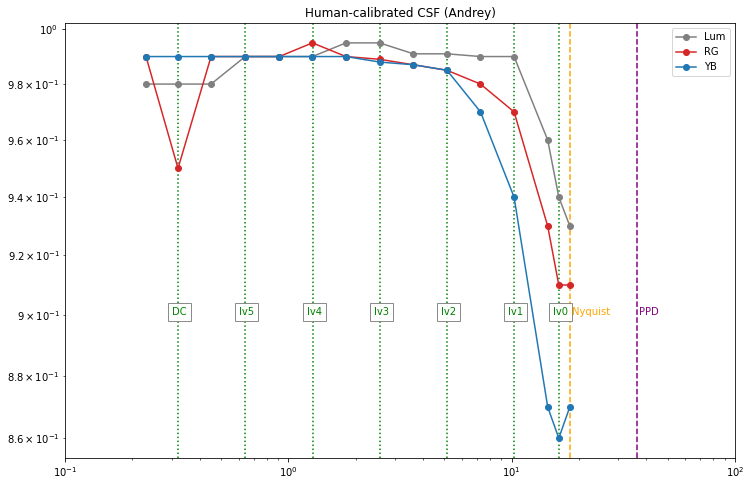

In [10]:

channel_names = ['Lum', ' RG', ' YB']
def lab_sinusoidal_gratings(cdeg, contrast,
                       gaussian_sigma = 25,
                       width_px = width_px,
                       height_px = 200,
                        show=False):
    """generates a set of low-contrast sinusoidal gratings
    separated across the three LAB perceptual channels"""
                       

    num_cycles = cdeg * (width_px/PPD)

#     f = num_cycles
#     w = 2. * np.pi * f
#     time_interval = num_px
#     samples = num_px
#     t = np.linspace(0, time_interval, samples)
#     y = np.sin(w * t)
#     # plt.plot(t, y)
#     plot_h = len(y) // 3
    

# def cos_freq(num_cycles, size):
#     w = 2. * np.pi * num_cycles
#     t = np.linspace(0, size, size)
#     sinusoid = np.cos(w*t) # cosine instead of sine to align the peaks with degrees
#     return sinusoid 

# # cycles = cos_freq(num_cycles = (num_degrees * example_cdeg), size=int(round((num_degrees+1)*PPD)))  #=int(round(width_px)))
# cycles = cos_freq(num_cycles = (num_degrees * example_cdeg), size=int(round(width_px)))  #=int(round(width_px)))

# # bg[:] = normalise(cycles)

# ### stack up the sine wave vertically:
# cycles2d = np.stack([cycles]*height_px)    
    
    cycles = cos_freq(num_cycles = num_cycles, 
                      size=width_px)

    z = normalise(np.stack([cycles]*height_px))

    # with gaussian smoothing over uniform grey background:
    bg = np.ones(z.shape)*0.5
    gauss = get_gaussian_kernel(z.shape, gaussian_sigma)
    zgauss = gauss * (z-0.5) # centred around 0

    # isolate sinusoidal grating:
    sg2d = zgauss * contrast
    zsoft = sg2d + bg # in [0,1] varying up and down from the background

    # ### cone ratio: 8 : 9.3 : 6.2
    # r_ratio = 8/9.3
    # b_ratio = 6.2/9.3

    ### perceptually-uniform addition in oklab space...
    ### display with changes only in luminance, RG, and YB:
    zsoft_rgb = np.stack([zsoft]*3, axis=2)
    zlab = srgb_to_oklab(zsoft_rgb)
    
    gratings = []
    
    for channel, chname in zip(range(3), channel_names):
        # print(f'\n==== Channel: {chname:>3} ====')
        zlab_ch = np.stack([np.ones(z.shape)*0.6] + [np.zeros(z.shape)]*2, axis=2) # grey luminance, zero chroma
        # add gaussian sinusoid in specific channel:
        zlab_ch[:,:,channel] += sg2d

        # reconstruct to rgb:
        zrgb_ch = oklab_to_srgb(zlab_ch)

        # # and add as gaussian mask over grayscale:
        # zrgb_ch_gauss = (zrgb_ch-0.5) * np.stack([gauss]*3, axis=2)
        # zsoft_rgb_ch = np.stack([bg]*3, axis=2) + (zrgb_ch_gauss)

        if show:
            rshow(zrgb_ch, normalised=False, vmin=0, vmax=1, title=f'{chname}  |  {cdeg:.1f} c/deg  |  {contrast} contrast')
        else:
            gratings.append(zrgb_ch)
    if not show:
        return gratings


    
### build calibration dict:

# for b in range(PYRAMID_SIZE):

# b = PYRAMID_SIZE-1
# print(f'Band level: {b}')

# c_freq = centre_freqs[b]
# u_freq, l_freq = outer_freqs[b]
all_freqs = sorted(list(set(centre_freqs + [b[0] for b in outer_freqs] + [b[1] for b in outer_freqs])), reverse=False)

INDEX = -1
CONTRAST = 0.1 # adjust until no longer visible

cdeg = all_freqs[INDEX]
cdeg = 16.26
print(f'{INDEX}. Creating gratings at frequency {cdeg:.2f} and contrast {CONTRAST}')

# for cdeg in u_freq, c_freq, l_freq:
gratings = lab_sinusoidal_gratings(cdeg=cdeg, contrast=CONTRAST)
glum, grb, gby = gratings

for g, chname in zip(gratings, channel_names):
    ax = rshow(g, normalised=False, vmin=0, vmax=1, title=f'{chname}  |  {cdeg:.2f} c/deg  |  {CONTRAST} contrast', show=False)

    plt.xticks(degrees_px.round())
    ax.set_xticklabels(degrees)
    # plt.yticks([])
    plt.xlabel('Degrees')
    plt.show()
print('\n=================\n')

    # highest contrast values at which the frequency becomes imperceptible:
freq_imperceptible_contrasts = {
     0.23: (0.02, 0.01, 0.01),
     0.32: (0.02, 0.05, 0.01), ## lv0 centre
     0.45: (0.02, 0.01, 0.01),
     0.64: (0.01, 0.01, 0.01), ## lv1 centre
     0.91: (0.01, 0.01, 0.01),
     1.28: (0.01, 0.005, 0.01), ## lv2 centre
     1.81: (0.005, 0.01, 0.01),
     2.56: (0.005, 0.011, 0.012),
     3.63: (0.009, 0.013, 0.013),
     5.13: (0.009, 0.015, 0.015),
     7.25: (0.01, 0.02, 0.03),
    10.25: (0.01, 0.03, 0.06),
    14.50: (0.04, 0.07, 0.13),
    16.26: (0.06, 0.09, 0.14),
    # 18.0 : (),
    18.22: (0.07, 0.09, 0.13), # noisy due to pixel aliasing artifacts at nyquist limit
                               }            
            
csf_calib_dict = {'base_sigma': BASE_SIGMA,
                  'pyramid_size': PYRAMID_SIZE,
                  'data': freq_imperceptible_contrasts,
                  'rater': 'Andrey'}

x = freq_imperceptible_contrasts.keys()
cal_lum = np.asarray([v[0] for k,v in freq_imperceptible_contrasts.items()])
cal_rg= np.asarray([v[1] for k,v in freq_imperceptible_contrasts.items()])
cal_yb = np.asarray([v[2] for k,v in freq_imperceptible_contrasts.items()])

fig = plt.figure(figsize=(12,8))
plt.plot(x, 1-cal_lum, 'o-', c='grey', label='Lum')
plt.plot(x, 1-cal_rg, 'o-', c='tab:red', label='RG')
plt.plot(x, 1-cal_yb, 'o-', c='tab:blue', label='YB')
plt.legend()
plt.xscale('log')
plt.xlim([1e-1, 1e2])
# plt.yscale('log')
# plt.ylim([1e-2, 1e4])

### add indicators for each centre freq:
for i, f in enumerate(centre_freqs):
    plt.axvline(f, linestyle=':', c='green', zorder=-99)
    plt.text(f*0.94, 0.9, s=f'lv{i}' if i!=(PYRAMID_SIZE-1) else 'DC', c='green', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='grey'))
# ### and for (upper bound of) outer freqs:
# for i, (fh,fl) in enumerate(outer_freqs): 
#     plt.axvline(fh, linestyle=':', lw=0.5, c='green', zorder=-100)

### and for Nyquist limit and pixel display resolution:
plt.axvline(PPD/2, linestyle='--', c='orange', zorder=-98)
plt.text(PPD*0.51, 0.9, s=f'Nyquist', c='orange')

plt.axvline(PPD, linestyle='--', c='purple', zorder=-99)
plt.text(PPD*1.02, 0.9, s=f'PPD', c='purple') # display limit where 1 cycle = 1 pixel

plt.title('Human-calibrated CSF (Andrey)')

plt.show()

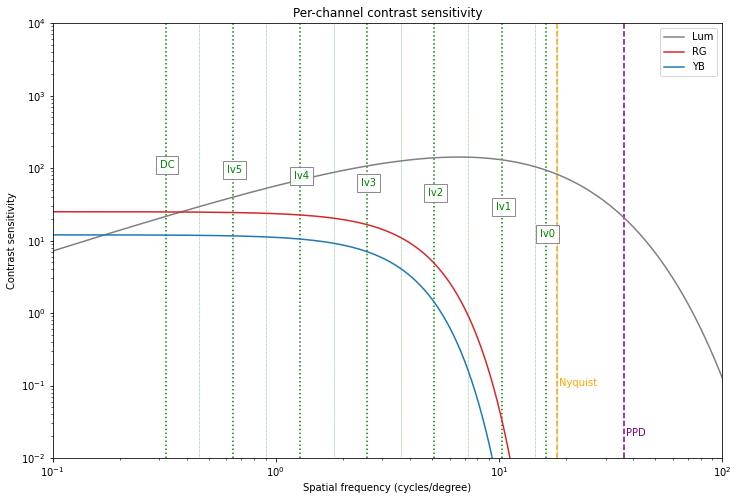

In [9]:
### CONTRAST SENSITIVITY FUNCTIONS

x = np.logspace(-2,2,500)

### first guess (but wrong values)
### approximate values from mantiuk:
lum = lum_csf(x) 
rg = rg_csf(x) 
yb = yb_csf(x) 

fig = plt.figure(figsize=(12,8))
plt.plot(x, lum, c='grey', label='Lum')
plt.plot(x, rg, c='tab:red', label='RG')
plt.plot(x, yb, c='tab:blue', label='YB')
plt.legend()

### add the frequencies of the laplacian pyramid:
PYRAMID_SIZE = 7
BASE_SIGMA = 0.4
pyramid = laplacian_pyramid(source_crop)

### calculate centre frequencies of each band:
centre_freqs = []
outer_freqs = []
for level in range(PYRAMID_SIZE):
    if level == 0:
        # Highpass band — center frequency is roughly halfway between
        # the first blur's cutoff and Nyquist
        cutoff = PPD / (2 * np.pi * BASE_SIGMA)
        nyquist = PPD / 2
        # centre_freq = (cutoff + nyquist) / 2 # arithmetic mean
        centre_freq = (cutoff * nyquist) ** 0.5 # geometric mean
        outer_freq = (nyquist, cutoff)
    else:
        sigma_low = BASE_SIGMA * (2 ** (level - 1))
        sigma_high = BASE_SIGMA * (2 ** level)
        # Cutoff frequency of a Gaussian with sigma s is ~ ppd / (2*pi*s)
        freq_low = PPD / (2 * np.pi * sigma_low)
        freq_high = PPD / (2 * np.pi * sigma_high)
        # centre_freq = (freq_low + freq_high) / 2
        centre_freq = (freq_low * freq_high) ** 0.5
        outer_freq = (freq_low, freq_high)
    centre_freqs.append(centre_freq)
    outer_freqs.append(outer_freq)

    
### add indicators for each centre freq:
for i, f in enumerate(centre_freqs):
    plt.axvline(f, linestyle=':', c='green', zorder=-99)
    plt.text(f*0.94, 15*(i+0.75), s=f'lv{i}' if i!=(PYRAMID_SIZE-1) else 'DC', c='green', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='grey'))
### and for (upper bound of) outer freqs:
for i, (fh,fl) in enumerate(outer_freqs): 
    plt.axvline(fh, linestyle=':', lw=0.5, c='green', zorder=-100)

### and for Nyquist limit and pixel display resolution:
plt.axvline(PPD/2, linestyle='--', c='orange', zorder=-98)
plt.text(PPD*0.51, 1e-1, s=f'Nyquist', c='orange')

plt.axvline(PPD, linestyle='--', c='purple', zorder=-99)
plt.text(PPD*1.02, 0.2e-1, s=f'PPD', c='purple') # display limit where 1 cycle = 1 pixel

# plt.axvline(cdeg, linestyle='-', c='black', zorder=-97)
# plt.text(cdeg*1.02, 3.5e-1, s=f'Plotted\nc/deg', c='k')

plt.xscale('log')
plt.xlim([1e-1, 1e2])
plt.yscale('log')
plt.ylim([1e-2, 1e4])

plt.xlabel('Spatial frequency (cycles/degree)')
plt.ylabel('Contrast sensitivity')
plt.title('Per-channel contrast sensitivity')

plt.show()

In [412]:
# peak_freqs = [max(f) for f in [lum, rg, yb]]
# r1, r2, r3 = [1, peak_freqs[1]/peak_freqs[0], peak_freqs[2]/peak_freqs[0]]
# print(f'Peak sensitivity ratios: 1 : {r2:.3f} : {r3:.3f}\n')

# calculate log sensitivity ratios where the least sensitive is equalised to 1:
cdeg_S = np.where(x > cdeg)[0][0]
cdeg_csf = np.asarray([np.log(csf[cdeg_S]) for csf in [lum, rg, yb]])
cdeg_csf -= (cdeg_csf.min())-1
cS_lum, cS_rg, cS_yb = cdeg_csf
# r1, r2, r3 = [1, cS_rg/cS_lum, cS_yb/cS_lum]
r1, r2, r3 = cdeg_csf
# print(f'Log sensitivity ratios at this c/deg:\nLum : RG : YB\n1 : {r2:.6f} : {r3:.6f}\n')
print(f'Log sensitivity ratios at this c/deg:\nLum : RG : YB\n{r1:.2f} : {r2:.2f} : 1.0\n')

pyramid_sensitivity = []

print(f'Perceptual sensitivity per channel at each pyramid level (low to high frequency)')
for level in list(range(PYRAMID_SIZE))[::-1]:
    # find the index where this pyramid's centre frequency sits:
    # (that is, the geometric mean of its cutoff frequencies)
    S = np.where(x > center_freqs[level])[0][0]
    
    print(f'\n  Level {level}: ({x[S]:.1f} cycles/deg)')
    for channel, chname in zip([lum, rg, yb], ['Lum', ' RG', ' YB']):
        print(f'    {chname}: {channel[S]:>8.5f}')
    pyramid_sensitivity.append((lum[S], rg[S], yb[S]))
    
pyramid_sensitivity = pyramid_sensitivity[::-1] # reverse again to go from level 0

#### sinusoidal gratings with fixed freq
### TODO: REDO with oklab luminance space. the colour scaling is too approximate

# fig = plt.figure(figsize=(figw,3))

print(f'Cycles/deg: {cdeg:.1f}')
Sx = np.where(x > cdeg)[0][0]
lumS = lum[Sx]
rgS = rg[Sx]
ybS = yb[Sx]
print(f'Sensitivity at this frequency: (and theoretical perceptible contrast)')
print(f'  Lum: {lumS:.3f} ({(1/lumS):.2%})')
print(f'   RG: {rgS:.3f} ({(1/rgS):.2%})')
print(f'   YB: {ybS:.3f} ({(1/ybS):.2%})')
# print(f'Luminance sensitivity at this frequency: {lumS:.3f}')
# print(f'Theoretical perceptible contrast: {(1/lumS):3e}')

Log sensitivity ratios at this c/deg:
Lum : RG : YB
3.39 : 1.81 : 1.0

Perceptual sensitivity per channel at each pyramid level (low to high frequency)

  Level 6: (0.2 cycles/deg)
    Lum: 14.56443
     RG: 24.93105
     YB: 11.95679

  Level 5: (0.4 cycles/deg)
    Lum: 27.66958
     RG: 24.72081
     YB: 11.82527

  Level 4: (0.8 cycles/deg)
    Lum: 49.51678
     RG: 23.92355
     YB: 11.32963

  Level 3: (1.7 cycles/deg)
    Lum: 83.36266
     RG: 20.90316
     YB:  9.49858

  Level 2: (3.4 cycles/deg)
    Lum: 121.58115
     RG: 12.39697
     YB:  4.80070

  Level 1: (6.8 cycles/deg)
    Lum: 141.97640
     RG:  1.44275
     YB:  0.28922

  Level 0: (13.6 cycles/deg)
    Lum: 109.90067
     RG:  0.00023
     YB:  0.00000
Cycles/deg: 2.0
Sensitivity at this frequency: (and theoretical perceptible contrast)
  Lum: 93.775 (1.07%)
   RG: 19.298 (5.18%)
   YB: 8.557 (11.69%)


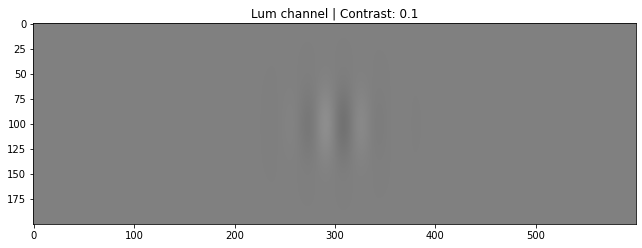

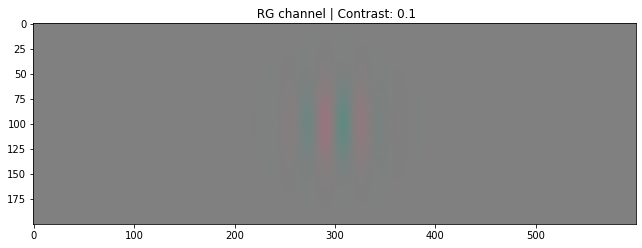

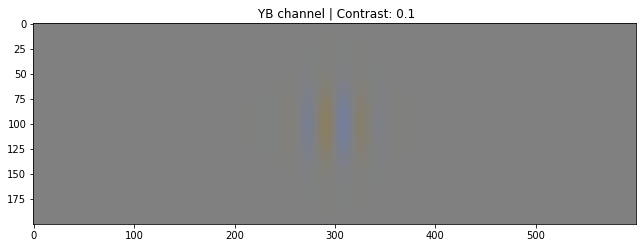